In [1]:
import sys
sys.path.append(r'C:\Users\Lenovo\Desktop\2025 ICM\2024_E\tools')
from IM_dataset import IM_dataset
from load_array import LoadArray
from mxnet import autograd,gluon,init
from animator import Animator

In [2]:
CM_data = IM_dataset(1000)

In [3]:
batch_size = 16
data_loader = LoadArray(CM_data,batch_size)

In [4]:
model = gluon.nn.Sequential()
model.add(

    # gluon.nn.Dense(64, activation='relu'),
    gluon.nn.Dense(32),
    gluon.nn.Dense(1)

)
model.initialize(init.Normal(sigma=0.01))

In [5]:
loss_func = gluon.loss.L2Loss()
optimizer = gluon.Trainer(model.collect_params(),'adam',{'learning_rate':0.01})

In [6]:
best_loss = float(100)

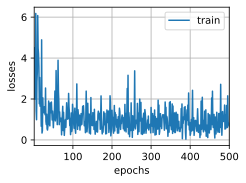

In [7]:
epochs = 500
animator = Animator(xlabel='epochs',ylabel='losses',legend=['train'],xlim=[1,epochs])
for epoch in range(epochs):
    epoch_loss = 0
    for feature, label in data_loader:
            with autograd.record():
                l = loss_func(model(feature),label)
                # print(feature,model(feature))
            l.backward()
            optimizer.step(batch_size)
            temp = l.mean().item()
            epoch_loss += temp
    animator.add(epoch+1, (temp,))

                

In [8]:
model[0].weight.data()

array([[ 1.0345519e+00, -2.9738095e-02, -9.4685847e-01],
       [ 1.0204107e+00, -3.0122604e-02, -9.4515091e-01],
       [-1.0333582e+00,  2.8230369e-02,  8.3983803e-01],
       [-5.5190051e-01,  3.3376995e-02,  2.0370576e+00],
       [-1.1104245e+00,  2.7781697e-02,  6.7289948e-01],
       [-1.0714968e+00,  2.7363550e-02,  7.3098981e-01],
       [ 2.2199820e-01, -6.4981785e-03, -1.1263983e-01],
       [ 1.0156066e+00, -2.5242722e-02, -4.3901145e-01],
       [ 3.6345893e-01, -3.6650613e-02, -2.5086160e+00],
       [-1.9921079e-01,  1.4666152e-01,  2.9844825e+00],
       [-1.0059839e+00,  3.1152189e-02,  1.0440010e+00],
       [-1.0781972e+00,  2.6553931e-02,  5.2018970e-01],
       [ 9.8281318e-01, -2.4330994e-02, -4.1777727e-01],
       [-1.0405500e+00,  2.8307576e-02,  8.5657585e-01],
       [ 1.0325389e+00, -2.7722232e-02, -8.5872793e-01],
       [ 1.5283932e-01, -2.1462192e-01, -3.0494027e+00],
       [-1.0420415e+00,  2.7555343e-02,  8.3062381e-01],
       [-1.0190884e+00,  2.9897

In [9]:
from mxnet import np, npx
npx.set_np()
feature = np.array([[130.67,	59.90, 	407






]])
model(feature)

array([[2222.9993]])